In [16]:
# ============================================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from colossus.cosmology import cosmology
from colossus.lss import mass_function, bias
from colossus.halo import concentration, mass_defs

print("Step 1: Imports successful")

Step 1: Imports successful


In [2]:
# ============================================================================
# CELL 2: SET UP COSMOLOGY (WMAP-7 from paper)
# ============================================================================
cosmo = cosmology.setCosmology('addison12',
    flat=True, H0=70.0, Om0=0.27, Ob0=0.045, sigma8=0.80, ns=0.96)

print("Step 2: Cosmology setup")
print(f"  H0 = {cosmo.H0:.1f} km/s/Mpc")
print(f"  Ωm = {cosmo.Om0:.3f}")
print(f"  σ8 = {cosmo.sigma8:.2f}")
print(f"  h = {cosmo.h:.2f}")

Step 2: Cosmology setup
  H0 = 70.0 km/s/Mpc
  Ωm = 0.270
  σ8 = 0.80
  h = 0.70


In [3]:
# ============================================================================
# CELL 3: DEFINE GRIDS FOR INTEGRATION
# ============================================================================
# Paper Section 3: Redshift range 0.01 to 6.0
z_arr = np.linspace(0.01, 6.0, 100)
print(f"\nStep 3: Redshift grid")
print(f"  {len(z_arr)} points from z={z_arr[0]:.2f} to {z_arr[-1]:.1f}")

# Mass range: 10^11.5 to 10^15.5 Msun/h (virial masses)
M_arr = np.logspace(11.5, 15.5, 80)
print(f"  Mass grid: {len(M_arr)} points")
print(f"  From {M_arr[0]:.2e} to {M_arr[-1]:.2e} Msun/h")

# Multipole range for CIB power spectrum
ell_arr = np.logspace(np.log10(1000), np.log10(10000), 50)
print(f"  Multipole grid: {len(ell_arr)} points")
print(f"  From ℓ={ell_arr[0]:.0f} to {ell_arr[-1]:.0f}")


Step 3: Redshift grid
  100 points from z=0.01 to 6.0
  Mass grid: 80 points
  From 3.16e+11 to 3.16e+15 Msun/h
  Multipole grid: 50 points
  From ℓ=1000 to 10000



Step 4: Computing halo mass function (Sheth-Tormen 1999)
  Paper Eq. (5): dn_h/dM appears in all integrals
  NOTE: sheth99 in Colossus uses FoF masses
  Paper Section 3.3: Uses virial masses, converts to M_500c for tSZ
  SOLUTION: Use FoF for mass function, approximate FoF ≈ M_180m ≈ M_vir
  ✓ Computed dn/dM
  Example at z=1, M=1e14: dn/dM = 4.239e-02 (h/Mpc)³/(Msun/h)


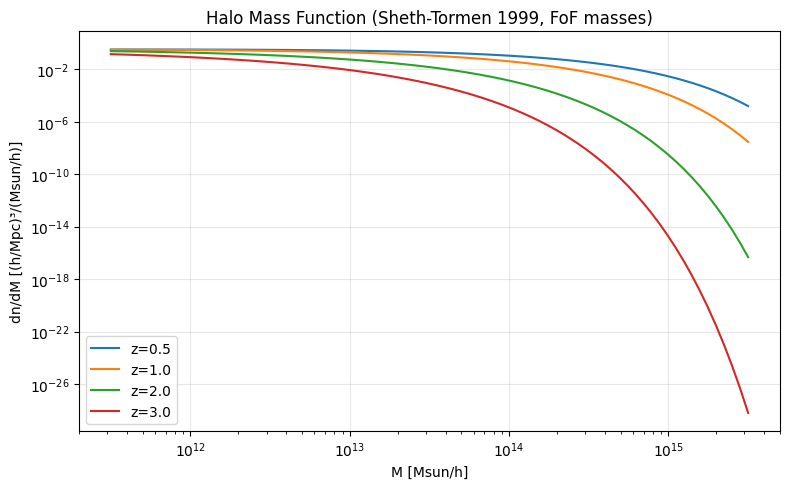

In [4]:
print("\nStep 4: Computing halo mass function (Sheth-Tormen 1999)")
print("  Paper Eq. (5): dn_h/dM appears in all integrals")
print("  NOTE: sheth99 in Colossus uses FoF masses")
print("  Paper Section 3.3: Uses virial masses, converts to M_500c for tSZ")
print("  SOLUTION: Use FoF for mass function, approximate FoF ≈ M_180m ≈ M_vir")

# Store dn/dM for all (z, M) combinations
dndM = np.zeros((len(z_arr), len(M_arr)))

for i, z in enumerate(z_arr):
    for j, M in enumerate(M_arr):
        # Sheth-Tormen 1999 - must use FoF in Colossus
        # In practice, FoF masses ≈ virial masses for standard b=0.2 linking length
        dndM[i, j] = mass_function.massFunction(M, z, mdef='fof', model='sheth99')

# Diagnostics
i_z1 = np.argmin(np.abs(z_arr - 1.0))
j_m14 = np.argmin(np.abs(M_arr - 1e14))
print(f"  ✓ Computed dn/dM")
print(f"  Example at z=1, M=1e14: dn/dM = {dndM[i_z1, j_m14]:.3e} (h/Mpc)³/(Msun/h)")

# Plot mass function at a few redshifts
plt.figure(figsize=(8, 5))
for z in [0.5, 1.0, 2.0, 3.0]:
    i_z = np.argmin(np.abs(z_arr - z))
    plt.loglog(M_arr, dndM[i_z, :], label=f'z={z:.1f}')
plt.xlabel('M [Msun/h]')
plt.ylabel('dn/dM [(h/Mpc)³/(Msun/h)]')
plt.title('Halo Mass Function (Sheth-Tormen 1999, FoF masses)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Step 5: CIB source model - dI_CIB/dz
  Paper uses Lapi et al. 2011 (L11) model
  Three populations: spirals, starbursts, proto-spheroids
  We use approximate values from paper's Figure 1
  ✓ CIB model set up for: [150, 217, 353] GHz


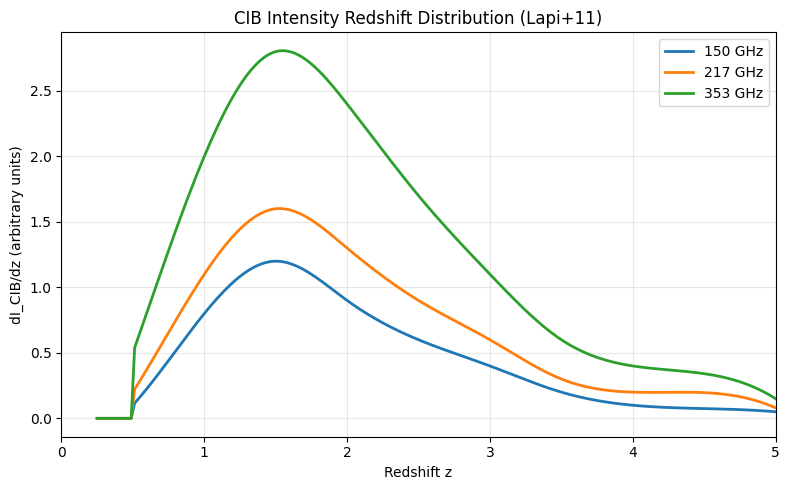

  Test: dI/dz(z=1.5, 150 GHz) = 1.20


In [9]:
#============================================================================
# CELL 5: SET UP CIB SOURCE MODEL (LAPI+11)
# ============================================================================
print("\nStep 5: CIB source model - dI_CIB/dz")
print("  Paper uses Lapi et al. 2011 (L11) model")
print("  Three populations: spirals, starbursts, proto-spheroids")
print("  We use approximate values from paper's Figure 1")

# Approximate dI_CIB/dz from Lapi+11 at different frequencies
# These are APPROXIMATE - the real L11 model is more complex
dICIB_dz_data = {
    150: {  # GHz
        'z': np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]),
        'dIdz': np.array([0.1, 0.8, 1.2, 0.9, 0.6, 0.4, 0.2, 0.1, 0.05])
    },
    217: {
        'z': np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]),
        'dIdz': np.array([0.2, 1.1, 1.6, 1.3, 0.9, 0.6, 0.3, 0.2, 0.08])
    },
    353: {
        'z': np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]),
        'dIdz': np.array([0.5, 2.0, 2.8, 2.4, 1.7, 1.1, 0.6, 0.4, 0.15])
    },
}

# Create interpolators
dICIB_interp = {}
for nu, data in dICIB_dz_data.items():
    dICIB_interp[nu] = interp1d(
        data['z'], data['dIdz'], 
        kind='cubic', fill_value=0, bounds_error=False
    )

def dICIB_dz(z, nu):
    """
    CIB intensity per unit redshift (arbitrary units)
    Paper excludes z < 0.25 for clustering calculations
    """
    if z < 0.25:
        return 0.0
    return dICIB_interp[nu](z)

print(f"  ✓ CIB model set up for: {list(dICIB_dz_data.keys())} GHz")

# Plot dI/dz
plt.figure(figsize=(8, 5))
z_plot = np.linspace(0.25, 5, 200)
for nu in dICIB_dz_data.keys():
    I_plot = [dICIB_dz(z, nu) for z in z_plot]
    plt.plot(z_plot, I_plot, label=f'{nu} GHz', lw=2)
plt.xlabel('Redshift z')
plt.ylabel('dI_CIB/dz (arbitrary units)')
plt.title('CIB Intensity Redshift Distribution (Lapi+11)')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

print(f"  Test: dI/dz(z=1.5, 150 GHz) = {dICIB_dz(1.5, 150):.2f}")


Step 6: Halo Occupation Distribution (HOD)
  Paper uses Xia+12 fitting to CIB clustering data
  HOD: <N_gal> = N_central + N_satellite
  HOD parameters:
    M_min = 1.74e+12 Msun/h (minimum halo mass)
    M_1   = 1.74e+13 Msun/h (satellite normalization)
    M_0   = 1.74e+12 Msun/h (satellite cutoff)
    α_sat = 1.81 (satellite power-law)


/tmp/ipykernel_40987/192199431.py:33: RuntimeWarning: invalid value encountered in power
  N_sat = np.where(M > M_0, N_c * ((M - M_0) / M_1)**alpha, 0.0)


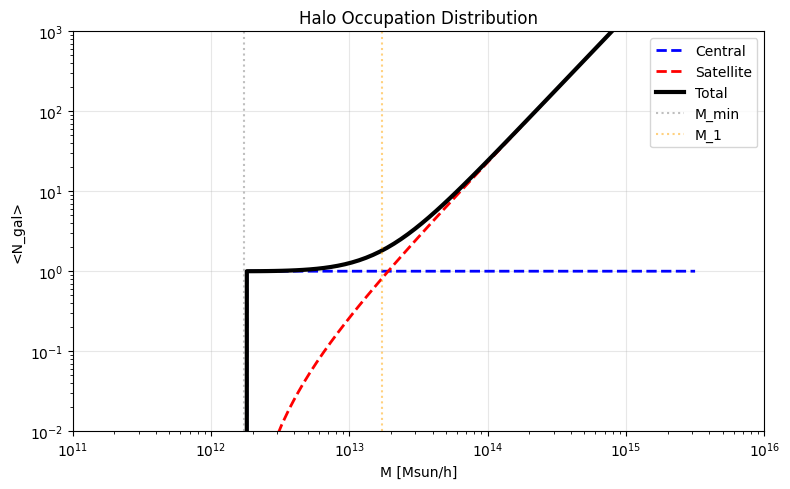


  Example: <N_gal>(M=1e14) = 24.00


In [6]:
# ============================================================================
# CELL 6: DEFINE HOD PARAMETERS (CORRECTED)
# ============================================================================
print("\nStep 6: Halo Occupation Distribution (HOD)")
print("  Paper uses Xia+12 fitting to CIB clustering data")
print("  HOD: <N_gal> = N_central + N_satellite")

# HOD parameters from Xia+12
log_M_min = 12.24  # log10(M_min/Msun)
alpha_sat = 1.81   # Satellite power-law index

M_min = 10**log_M_min
M_1 = 10 * M_min  # Characteristic mass should be ~10x larger than M_min
M_0 = M_min       # Cutoff mass for satellites (standard choice)

print(f"  HOD parameters:")
print(f"    M_min = {M_min:.2e} Msun/h (minimum halo mass)")
print(f"    M_1   = {M_1:.2e} Msun/h (satellite normalization)")
print(f"    M_0   = {M_0:.2e} Msun/h (satellite cutoff)")
print(f"    α_sat = {alpha_sat:.2f} (satellite power-law)")

def N_central(M, M_min):
    """Number of central galaxies (0 or 1)"""
    return np.where(M > M_min, 1.0, 0.0)

def N_satellite(M, M_min, M_0, M_1, alpha):
    """
    Mean number of satellite galaxies
    Standard HOD form: <N_sat> = ((M - M_0)/M_1)^alpha for M > M_min
    """
    N_c = N_central(M, M_min)
    # Only add satellites if halo has a central
    N_sat = np.where(M > M_0, N_c * ((M - M_0) / M_1)**alpha, 0.0)
    return N_sat

def N_total(M, M_min, M_0, M_1, alpha):
    """Total mean occupation <N_gal>"""
    return N_central(M, M_min) + N_satellite(M, M_min, M_0, M_1, alpha)

# Plot HOD
plt.figure(figsize=(8, 5))
N_cen = N_central(M_arr, M_min)
N_sat = N_satellite(M_arr, M_min, M_0, M_1, alpha_sat)
N_tot = N_total(M_arr, M_min, M_0, M_1, alpha_sat)

plt.loglog(M_arr, N_cen, 'b--', label='Central', lw=2)
plt.loglog(M_arr, N_sat, 'r--', label='Satellite', lw=2)
plt.loglog(M_arr, N_tot, 'k-', label='Total', lw=3)
plt.axvline(M_min, color='gray', ls=':', alpha=0.5, label=f'M_min')
plt.axvline(M_1, color='orange', ls=':', alpha=0.5, label=f'M_1')
plt.xlabel('M [Msun/h]')
plt.ylabel('<N_gal>')
plt.title('Halo Occupation Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0.01, 1000)
plt.xlim(1e11, 1e16)
plt.tight_layout()
plt.show()

# Diagnostics
M_test = 1e14
N_test = N_total(M_test, M_min, M_0, M_1, alpha_sat)
print(f"\n  Example: <N_gal>(M=1e14) = {N_test:.2f}")

In [11]:
# ============================================================================
# CELL 7: COMPUTE CIB ONE-HALO POWER (EQUATION 13)
# ============================================================================
print("\nStep 7: CIB One-Halo Power Spectrum")
print("  Paper Eq. (13): C_CIB-1h involves <N(N-1)>")
print("  Assumes CIB sources trace dark matter within r_vir")

nu_freq = 150  # GHz

# For one-halo term: <N(N-1)> ≈ <N_sat>(<N_sat> + 2<N_cen>)
def N_pairs(M, M_min, M_0, M_1, alpha):
    """<N_gal(N_gal - 1)> for one-halo term"""
    N_c = N_central(M, M_min)
    N_s = N_satellite(M, M_min, M_0, M_1, alpha)
    # <N(N-1)> = <N_sat^2> + 2<N_cen><N_sat>
    # Approximation: <N_sat^2> ≈ <N_sat>^2 for large haloes
    return N_s * (N_s + 2 * N_c)

# NFW profile Fourier transform (simplified)
def u_NFW(k, M, z):
    """
    Fourier transform of NFW profile (normalized to 1 at k=0)
    Simplified calculation
    """
    # Get concentration for FoF masses
    try:
        c = concentration.concentration(M, 'fof', z, model='child18')
    except:
        # Fallback: use typical concentration
        c = 5.0 / (1 + z)**0.3  # Simple redshift evolution
    
    # Virial radius (approximation for FoF)
    rho_c = cosmo.rho_c(z)  # Msun h^2 / Mpc^3
    Delta_vir = 200 * cosmo.Om(z)  # Virial overdensity (approx)
    r_vir = (3 * M / (4 * np.pi * Delta_vir * rho_c))**(1/3)
    r_s = r_vir / c
    
    # Simplified NFW Fourier transform
    x = k * r_s
    # For x << 1, u ≈ 1; for x >> 1, u ∝ 1/x^2
    # Approximate form (not exact but reasonable)
    u = 1.0 / (1.0 + x**2)
    
    return u

print("  Computing one-halo power...")

C_1h = np.zeros_like(ell_arr)

for idx_l, ell in enumerate(ell_arr):
    if idx_l % 10 == 0:
        print(f"    ℓ = {ell:.0f}")
    
    # Integrate over redshift
    for i, z in enumerate(z_arr[:-1]):
        dz = z_arr[i+1] - z_arr[i]
        
        # Comoving distance
        chi = cosmo.comovingDistance(0, z)
        
        # Comoving volume element
        H_z = cosmo.Hz(z)  # km/s/Mpc
        c_light = 299792.458  # km/s
        dchi_dz = c_light / H_z
        dVdz = chi**2 * dchi_dz
        
        # Wavenumber
        k = ell / chi
        
        # CIB intensity at this z
        I_cib = dICIB_dz(z, nu_freq)
        if I_cib == 0:
            continue
        
        # Integrate over mass
        mass_integral = 0.0
        for j, M in enumerate(M_arr[:-1]):
            dM = np.log(M_arr[j+1] / M_arr[j]) * M_arr[j]
            
            # Halo properties
            dn = dndM[i, j]
            N_pair = N_pairs(M, M_min, M_0, M_1, alpha_sat)
            u = u_NFW(k, M, z)
            
            # Paper Eq. (13): <S>^2 <N(N-1)> u^2
            # Using I_cib as proxy for <S>
            mass_integral += dn * I_cib**2 * N_pair * u**2 * dM
        
        C_1h[idx_l] += dVdz * dz * mass_integral

# Convert to D_ell
D_1h = ell_arr * (ell_arr + 1) * C_1h / (2 * np.pi)

print(f"  ✓ One-halo power computed")
print(f"  D_1h at ℓ=3000: {np.interp(3000, ell_arr, D_1h):.2e} (arbitrary units)")



Step 7: CIB One-Halo Power Spectrum
  Paper Eq. (13): C_CIB-1h involves <N(N-1)>
  Assumes CIB sources trace dark matter within r_vir
  Computing one-halo power...
    ℓ = 1000
    ℓ = 1600


/tmp/ipykernel_40987/192199431.py:33: RuntimeWarning: invalid value encountered in scalar power
  N_sat = np.where(M > M_0, N_c * ((M - M_0) / M_1)**alpha, 0.0)


    ℓ = 2560
    ℓ = 4095
    ℓ = 6551
  ✓ One-halo power computed
  D_1h at ℓ=3000: 4.12e+23 (arbitrary units)



Step 8: Computing halo bias
  Paper uses Sheth-Mo-Tormen 2001 bias
  Using FoF masses (consistent with mass function)
  ✓ Halo bias computed
  Example at z=1, M=1e14: b = 4.72


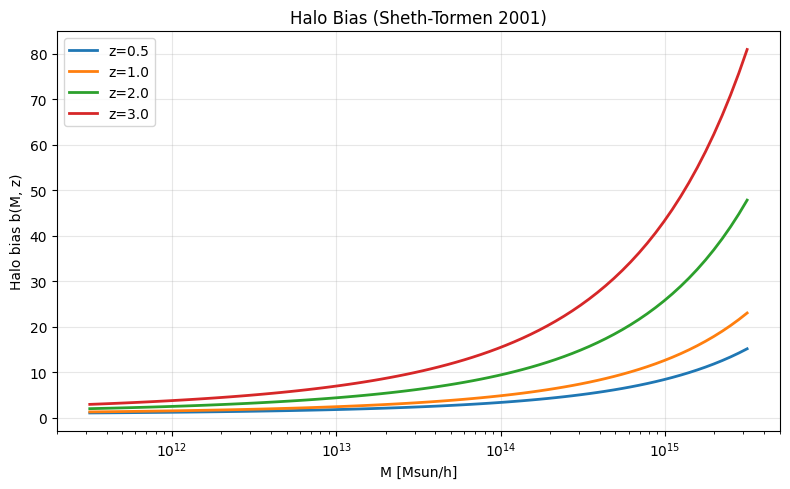

In [18]:
# ============================================================================
# CELL 8: COMPUTE HALO BIAS
# ============================================================================
print("\nStep 8: Computing halo bias")
print("  Paper uses Sheth-Mo-Tormen 2001 bias")
print("  Using FoF masses (consistent with mass function)")

b_h = np.zeros((len(z_arr), len(M_arr)))

for i, z in enumerate(z_arr):
    for j, M in enumerate(M_arr):
        # Use bias model consistent with Sheth-Tormen mass function
        b_h[i, j] = bias.haloBias(M, z, mdef='fof', model='sheth01')

print(f"  ✓ Halo bias computed")
print(f"  Example at z=1, M=1e14: b = {b_h[i_z1, j_m14]:.2f}")

# Plot bias
plt.figure(figsize=(8, 5))
for z in [0.5, 1.0, 2.0, 3.0]:
    i_z = np.argmin(np.abs(z_arr - z))
    plt.semilogx(M_arr, b_h[i_z, :], label=f'z={z:.1f}', lw=2)
plt.xlabel('M [Msun/h]')
plt.ylabel('Halo bias b(M, z)')
plt.title('Halo Bias (Sheth-Tormen 2001)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================================
# CELL 9: COMPUTE CIB TWO-HALO POWER (EQUATION 14)
# ============================================================================
print("\nStep 9: CIB Two-Halo Power Spectrum")
print("  Paper Eq. (14): C_CIB-2h involves P_DM(k,z) and b_h")

C_2h = np.zeros_like(ell_arr)

print("  Computing two-halo power...")

for idx_l, ell in enumerate(ell_arr):
    if idx_l % 10 == 0:
        print(f"    ℓ = {ell:.0f}")
    
    for i, z in enumerate(z_arr[:-1]):
        dz = z_arr[i+1] - z_arr[i]
        
        chi = cosmo.comovingDistance(0, z)
        H_z = cosmo.Hz(z)
        c_light = 299792.458
        dchi_dz = c_light / H_z
        dVdz = chi**2 * dchi_dz
        
        k = ell / chi
        
        # Dark matter power spectrum
        P_dm = cosmo.matterPowerSpectrum(k, z)
        
        I_cib = dICIB_dz(z, nu_freq)
        if I_cib == 0:
            continue
        
        # First mass integral
        integral1 = 0.0
        for j, M in enumerate(M_arr[:-1]):
            dM = np.log(M_arr[j+1] / M_arr[j]) * M_arr[j]
            
            dn = dndM[i, j]
            bh = b_h[i, j]
            N_tot = N_total(M, M_min, M_0, M_1, alpha_sat)
            u = u_NFW(k, M, z)
            
            # Paper Eq. (14): ∫ dM dn/dM b_h <S> <N> u
            integral1 += dn * bh * I_cib * N_tot * u * dM
        
        # Two-halo: square of the integral times P_DM
        C_2h[idx_l] += dVdz * dz * P_dm * integral1**2

D_2h = ell_arr * (ell_arr + 1) * C_2h / (2 * np.pi)

print(f"  ✓ Two-halo power computed")
print(f"  D_2h at ℓ=3000: {np.interp(3000, ell_arr, D_2h):.2e} (arbitrary units)")


Step 9: CIB Two-Halo Power Spectrum
  Paper Eq. (14): C_CIB-2h involves P_DM(k,z) and b_h
  Computing two-halo power...
    ℓ = 1000
    ℓ = 1600


/tmp/ipykernel_40987/192199431.py:33: RuntimeWarning: invalid value encountered in scalar power
  N_sat = np.where(M > M_0, N_c * ((M - M_0) / M_1)**alpha, 0.0)


    ℓ = 2560
    ℓ = 4095
    ℓ = 6551
  ✓ Two-halo power computed
  D_2h at ℓ=3000: 7.75e+38 (arbitrary units)



Step 10: Total CIB Clustered Power
  C_CIB = C_1h + C_2h (Paper Eq. 12)
  ✓ Total CIB clustered power:
    At ℓ=3000:
      D_1h  = 4.12e+23
      D_2h  = 7.75e+38
      Total = 7.75e+38


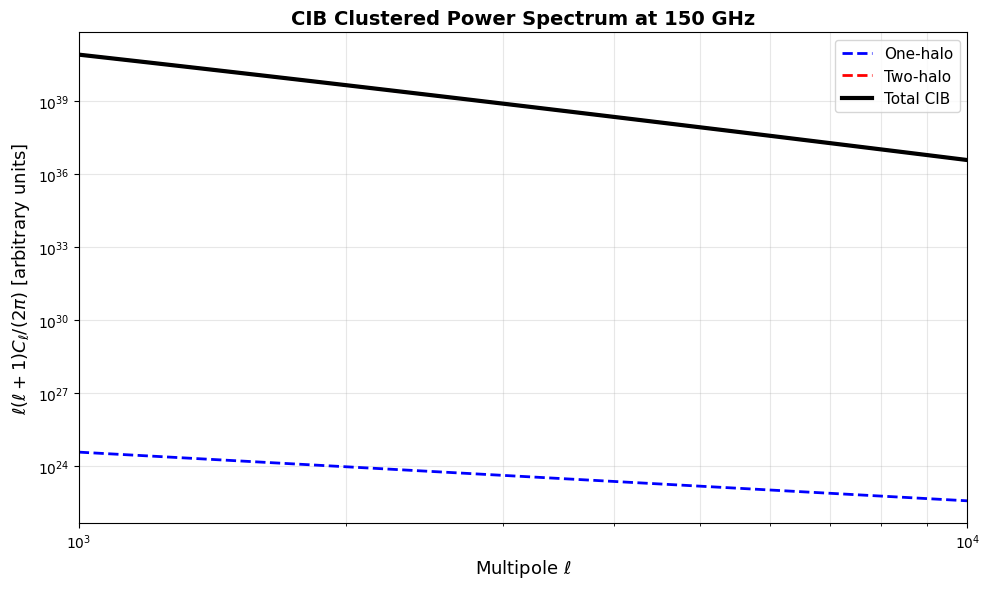


CIB HALO MODEL COMPLETE!
Next steps:
  1. Normalize to match observed CIB clustering
  2. Add Poisson shot noise component
  3. Validate against Planck/SPT/ACT data


In [20]:
# ============================================================================
# CELL 10: TOTAL CIB CLUSTERED POWER AND PLOT
# ============================================================================
print("\nStep 10: Total CIB Clustered Power")
print("  C_CIB = C_1h + C_2h (Paper Eq. 12)")

D_cib_total = D_1h + D_2h

print(f"  ✓ Total CIB clustered power:")
print(f"    At ℓ=3000:")
print(f"      D_1h  = {np.interp(3000, ell_arr, D_1h):.2e}")
print(f"      D_2h  = {np.interp(3000, ell_arr, D_2h):.2e}")
print(f"      Total = {np.interp(3000, ell_arr, D_cib_total):.2e}")

# Plot
plt.figure(figsize=(10, 6))
plt.loglog(ell_arr, D_1h, 'b--', label='One-halo', lw=2)
plt.loglog(ell_arr, D_2h, 'r--', label='Two-halo', lw=2)
plt.loglog(ell_arr, D_cib_total, 'k-', label='Total CIB', lw=3)
plt.xlabel('Multipole $\\ell$', fontsize=13)
plt.ylabel('$\\ell(\\ell+1)C_\\ell/(2\\pi)$ [arbitrary units]', fontsize=13)
plt.title(f'CIB Clustered Power Spectrum at {nu_freq} GHz', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3, which='both')
plt.xlim(1000, 10000)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CIB HALO MODEL COMPLETE!")
print("="*60)
print("Next steps:")
print("  1. Normalize to match observed CIB clustering")
print("  2. Add Poisson shot noise component")
print("  3. Validate against Planck/SPT/ACT data")
print("="*60)
